In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Ali_Sharaf\Downloads\kidney_disease (1).csv")

display(df.head())

print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns\n")

df.info()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd



Shape: 400 rows, 26 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc   

In [5]:
display(df.head())

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
print(df.columns.tolist())

['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
sns.set_theme(style="whitegrid")

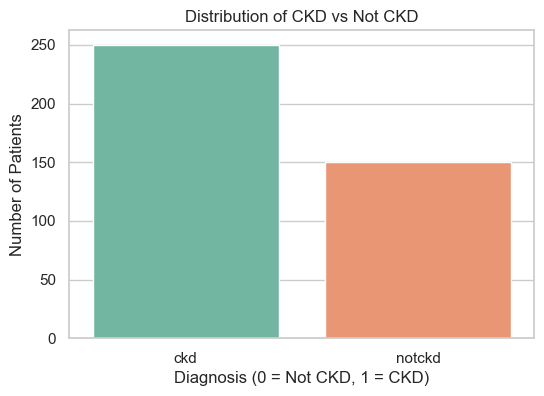

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='classification', hue='classification', palette='Set2', legend=False)
plt.title('Distribution of CKD vs Not CKD')
plt.xlabel('Diagnosis (0 = Not CKD, 1 = CKD)')
plt.ylabel('Number of Patients')
plt.show()

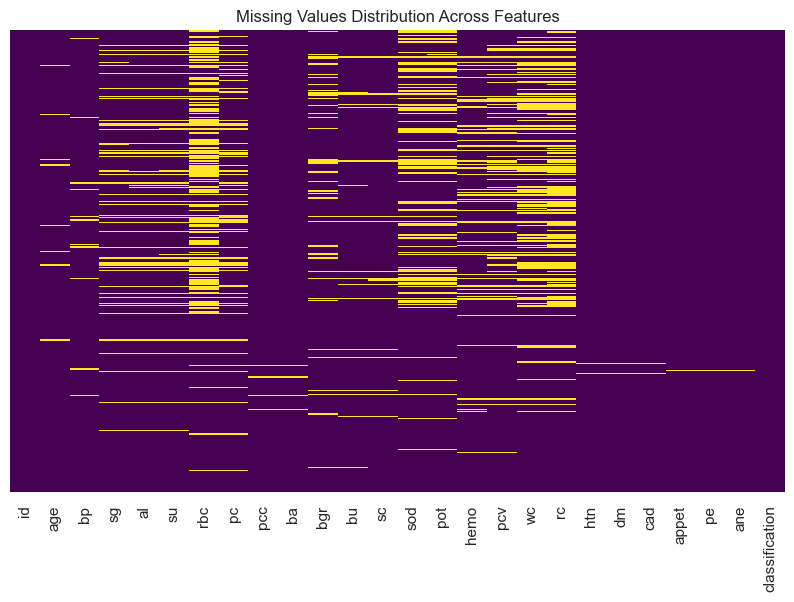

In [24]:
plt.figure(figsize=(10, 6))
# الرسمة دي بتوضح أماكن الـ Nulls باللون الأصفر
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Distribution Across Features')
plt.show()

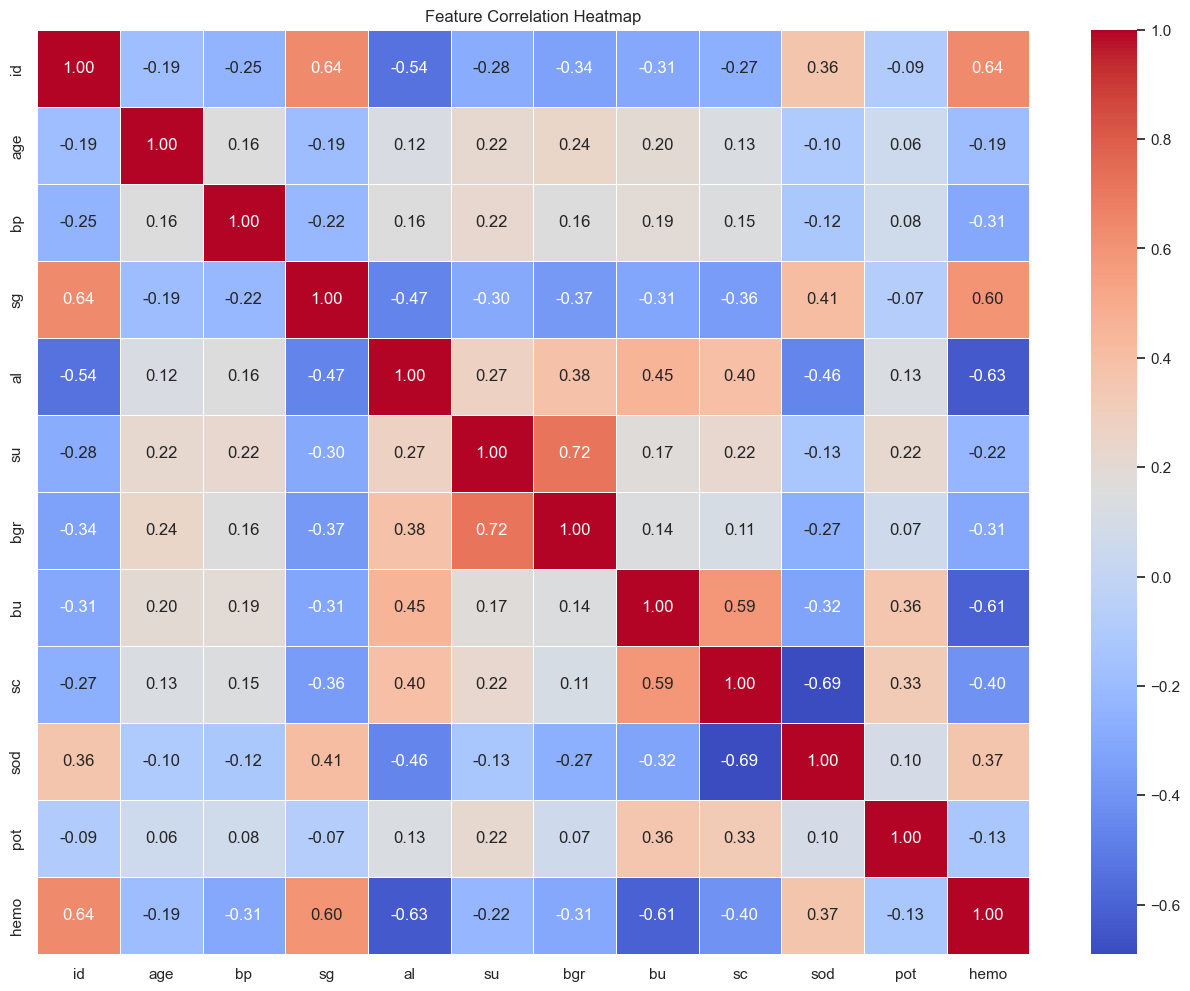

In [25]:
plt.figure(figsize=(16, 12))
# بنحسب الارتباط للأرقام بس عشان نتجنب أي إيرور
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

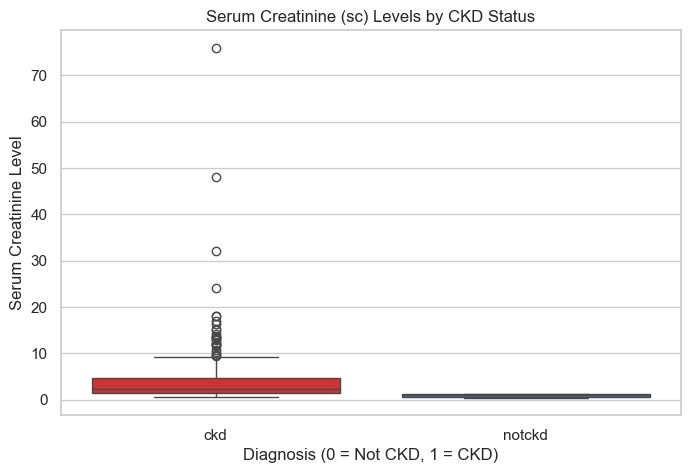

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='classification', y='sc', hue='classification', palette='Set1', legend=False)
plt.title('Serum Creatinine (sc) Levels by CKD Status')
plt.xlabel('Diagnosis (0 = Not CKD, 1 = CKD)')
plt.ylabel('Serum Creatinine Level')
plt.show()

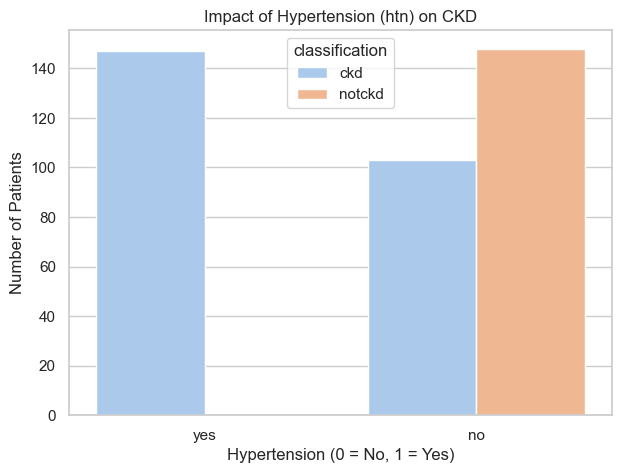

In [28]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='htn', hue='classification', palette='pastel')
plt.title('Impact of Hypertension (htn) on CKD')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. قراءة البيانات من البداية عشان نضمن إن الداتا لسه نصوص
df = pd.read_csv(r"C:\Users\Ali_Sharaf\Downloads\kidney_disease (1).csv")

# 2. التنظيف ومعالجة القيم المفقودة (Data Cleaning & Imputation)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# تنظيف عمود التشخيص بأمان 
df['classification'] = df['classification'].astype(str).str.strip()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})
df['classification'] = df['classification'].fillna(df['classification'].mode()[0])

# ملء الفراغات في باقي التحاليل (المتوسط للأرقام، والأكثر تكراراً للنصوص)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# 3. تحويل النصوص لأرقام (Label Encoding)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ==========================================
# 4. اختيار أهم 5 خصائص طبية (Feature Selection)
# ==========================================
selected_features = ['sg', 'al', 'sc', 'hemo', 'bp']

X = df[selected_features]
y = df['classification']

# 5. تقسيم البيانات (80% تدريب - 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. تدريب الموديل (Random Forest)
# قللنا العمق (max_depth=3) عشان الموديل ميحفظش الداتا ويدينا دقة واقعية
rf_model = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

# 7. التقييم وعرض النتائج (Evaluation)
y_pred = rf_model.predict(X_test)

print("=== Final Model Evaluation ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

=== Final Model Evaluation ===
Accuracy Score: 97.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.98      0.98      0.98        52

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



In [53]:
import joblib

# حفظ الموديل في ملف 
joblib.dump(rf_model, 'kidney_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [54]:
import joblib

# حفظ الموديل في الفولدر بتاعك مباشرة على الديسكتوب
save_path = r"C:\Users\Ali_Sharaf\Desktop\New folder\kidney_model.pkl"

joblib.dump(rf_model, save_path)

print("Model Saved Successfully in New folder!")

Model Saved Successfully in New folder!
